# Class Thread Model — Demo

This notebook demonstrates the **Class Thread** dual-node knowledge model.

Every concept is represented by **two** nodes:

* an **abstract** node — the *intension* (the idea of the concept)
* an **extension** node — the *set of all instances* of the concept

linked by a `hasExtension` edge. A **Class Thread** is the forward directed path:

> `hasExtension` -> (zero or more `supersetOf`) -> `hasElement`

connecting a concept's abstract node down to one of its instances.

We'll: load a flat graph -> expand it (Process 1) -> validate & break & repair
threads (Process 2) -> print metrics -> compare flat vs. threaded queries -> visualize.

In [1]:
# Make the project importable and resolve relative paths (config.yaml, data/)
import sys, os
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s %(name)s: %(message)s')

import networkx as nx
import matplotlib.pyplot as plt
%matplotlib inline

from src import graph_utils as gu
from src import process1_dual_node as p1
from src import process2_thread_enforce as p2
from src import metrics as m

cfg = gu.load_config('config.yaml')
print('Working dir:', os.getcwd())
print('Relations:', gu.get_relations(cfg))

Working dir: /Users/wds4/repos/nous-clawds4/class-threads-project
Relations: {'has_extension': 'hasExtension', 'sub_class_of': 'subClassOf', 'instance_of': 'instanceOf', 'superset_of': 'supersetOf', 'has_element': 'hasElement'}


## 1. Load the flat graph (the *before* state)

A flat graph uses one node per concept and one per instance, with `subClassOf`
(child -> parent) and `instanceOf` (instance -> concept) edges. We use a small,
controllable animal/vehicle taxonomy.

In [2]:
flat = gu.load_graph_from_config(cfg)
print('Flat graph summary:', gu.describe_graph(flat))

INFO src.graph_utils: Built synthetic flat graph: 18 nodes, 16 edges (10 concepts, 8 instances).


Flat graph summary: {'nodes': 18, 'edges': 16, 'node_kinds': {'concept': 10, 'instance': 8}, 'relations': {'subClassOf': 8, 'instanceOf': 8}}


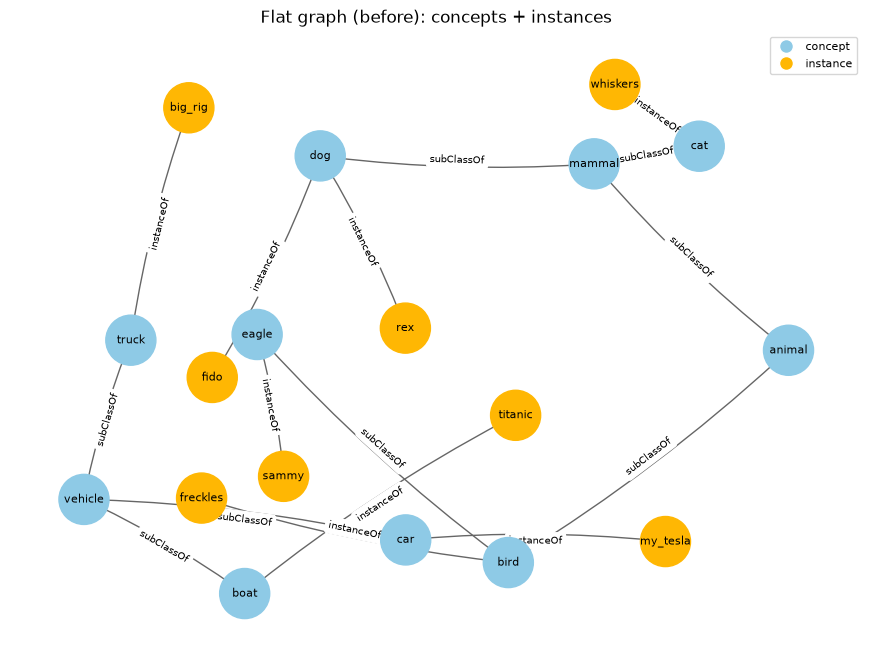

In [3]:
fig, ax = plt.subplots(figsize=(11, 8))
gu.visualize(flat, title='Flat graph (before): concepts + instances', ax=ax)
plt.show()

## 2. Process 1 — Dual-Node Expansion

Each concept `C` is split into `abstract:C` and `extension:C` (linked by
`hasExtension`). Edges are rewired so a Class Thread is a literal forward path:

* `supersetOf` : `extension:parent -> extension:child` (general -> specific; thread-bearing)
* `hasElement` : `extension:C -> instance`
* `subClassOf` : `abstract:child -> abstract:parent` (conventional mirror, for fidelity)

In [4]:
dual = p1.expand_to_dual_nodes(flat, config=cfg)
print('Dual graph summary:', gu.describe_graph(dual))

INFO src.process1_dual_node: Process 1: expanding 10/10 concept(s).


INFO src.process1_dual_node: Process 1 done: 28 nodes, 34 edges (10 abstract, 10 extension, 8 instance).


Dual graph summary: {'nodes': 28, 'edges': 34, 'node_kinds': {'abstract': 10, 'extension': 10, 'instance': 8}, 'relations': {'hasExtension': 10, 'subClassOf': 8, 'supersetOf': 8, 'hasElement': 8}}


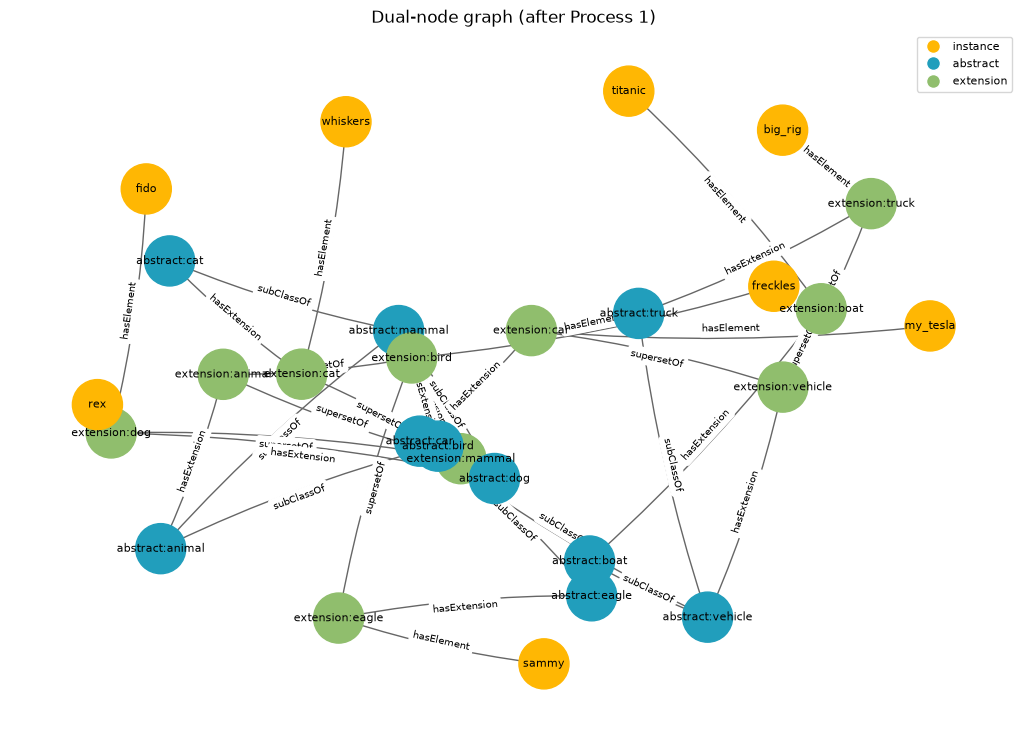

In [5]:
fig, ax = plt.subplots(figsize=(13, 9))
gu.visualize(dual, title='Dual-node graph (after Process 1)', ax=ax)
plt.show()

### What a Class Thread looks like

`find_thread` returns the actual node path matching `hasExtension -> supersetOf* -> hasElement`.

In [6]:
path = p2.find_thread(dual, 'animal', 'rex', cfg)
labels = [dual.edges[path[i], path[i+1]]['relation'] for i in range(len(path)-1)]
print('Thread  animal -> rex:')
print('  nodes :', ' -> '.join(path))
print('  edges :', ' , '.join(labels))

Thread  animal -> rex:
  nodes : abstract:animal -> extension:animal -> extension:mammal -> extension:dog -> rex
  edges : hasExtension , supersetOf , supersetOf , hasElement


## 3. Validate threads + baseline metrics

On the freshly-expanded graph every expected (instance, concept) pair should be
covered. We snapshot the expected pairs now so they remain our ground truth even
after we deliberately damage the graph below.

In [7]:
report_pristine = p2.validate_threads(dual, config=cfg)
EXPECTED = set(report_pristine.expected)  # ground-truth snapshot
print(m.format_metrics(m.compute_metrics(dual, config=cfg, report=report_pristine)))

INFO src.process2_thread_enforce: Validation: {'expected_pairs': 20, 'valid_pairs': 20, 'broken_pairs': 0, 'coverage': 1.0}


  coverage                       : 100.0%  (20/20 pairs)
  broken threads                 : 0
  instances                      : 8
  avg valid threads / instance   : 2.5


## 4. Break some threads (simulate incomplete data)

We remove a `supersetOf` edge (a gap in the taxonomy) and a `hasExtension` edge
(a concept whose extension got disconnected). This should drop coverage.

In [8]:
# Snapshot for side-by-side viz later
import copy
dual_pristine = copy.deepcopy(dual)

dual.remove_edge('extension:animal', 'extension:mammal')  # taxonomy gap
dual.remove_edge('abstract:car', 'extension:car')         # disconnected extension
print('Removed: extension:animal -[supersetOf]-> extension:mammal')
print('Removed: abstract:car -[hasExtension]-> extension:car')

report_before = p2.validate_threads(dual, config=cfg, expected=EXPECTED)
print()
print(m.format_metrics(m.compute_metrics(dual, config=cfg, report=report_before)))
print('Broken pairs:', sorted(f'{i}~{c}' for i, c in report_before.broken))

INFO src.process2_thread_enforce: Validation: {'expected_pairs': 20, 'valid_pairs': 16, 'broken_pairs': 4, 'coverage': 0.8}


INFO src.process2_thread_enforce: Broken threads (4): fido~animal, my_tesla~car, rex~animal, whiskers~animal


Removed: extension:animal -[supersetOf]-> extension:mammal
Removed: abstract:car -[hasExtension]-> extension:car

  coverage                       : 80.0%  (16/20 pairs)
  broken threads                 : 4
  instances                      : 8
  avg valid threads / instance   : 2.0
Broken pairs: ['fido~animal', 'my_tesla~car', 'rex~animal', 'whiskers~animal']


## 5. Process 2 — Enforcement & conservative repair

Repair proposes only the *minimal* canonical edges and applies those at/above the
confidence threshold (`config.process2.repair.min_confidence`). Structural edges
(`hasExtension`=1.0, taxonomy-attested `supersetOf`=0.9) are added; inventing a
membership (`hasElement`=0.55) is skipped under the default 0.75 gate.

In [9]:
result = p2.repair_threads(dual, config=cfg, report=report_before)
print('Repair summary:', result.summary())
print()
for r in result.added:
    print(f"  +ADDED  {r['u']} -[{r['relation']}]-> {r['v']}  (conf {r['confidence']}) : {r['reason']}")
for r in result.skipped:
    print(f"  -SKIP   {r['u']} -[{r['relation']}]-> {r['v']}  ({r['skip_reason']})")

INFO src.process2_thread_enforce: Repair +edge abstract:car -[hasExtension]-> extension:car (conf=1.00): hasExtension structurally implied for 'car'


INFO src.process2_thread_enforce: Repair +edge extension:animal -[supersetOf]-> extension:mammal (conf=0.90): supersetOf attested by taxonomy: animal -> mammal


INFO src.process2_thread_enforce: Repair: {'edges_added': 2, 'edges_skipped': 0}


Repair summary: {'edges_added': 2, 'edges_skipped': 0}

  +ADDED  abstract:car -[hasExtension]-> extension:car  (conf 1.0) : hasExtension structurally implied for 'car'
  +ADDED  extension:animal -[supersetOf]-> extension:mammal  (conf 0.9) : supersetOf attested by taxonomy: animal -> mammal


In [10]:
report_after = p2.validate_threads(dual, config=cfg, expected=EXPECTED)
print('Before -> After enforcement:')
print(m.format_delta(m.enforcement_delta(report_before, report_after)))

INFO src.process2_thread_enforce: Validation: {'expected_pairs': 20, 'valid_pairs': 20, 'broken_pairs': 0, 'coverage': 1.0}


Before -> After enforcement:
  coverage   : 80.0%  ->  100.0%
  broken     : 4  ->  0   (4 repaired)
  restored   : fido~animal, my_tesla~car, rex~animal, whiskers~animal


## 6. Flat vs. Threaded queries (the payoff)

Question: *give me all instances of `animal`.*

* **flat_direct** — naive 1-hop `instanceOf`; misses anything that belongs only via a subclass.
* **flat_transitive** — correct, but needs a bespoke recursive walk over `subClassOf` + `instanceOf`.
* **threaded** — one uniform pattern `hasExtension -> supersetOf* -> hasElement`.

In [11]:
for concept in ['animal', 'mammal', 'vehicle']:
    qc = m.query_comparison(flat, dual, concept, cfg)
    print(f"=== all instances of '{concept}' ===")
    print('  flat_direct      :', qc['flat_direct'])
    print('  flat_transitive  :', qc['flat_transitive'])
    print('  threaded         :', qc['threaded'])
    print('  naive misses     :', qc['flat_direct_misses'])
    print('  threaded==correct:', qc['threaded_matches_transitive'])
    print()

=== all instances of 'animal' ===
  flat_direct      : []
  flat_transitive  : ['fido', 'freckles', 'rex', 'sammy', 'whiskers']
  threaded         : ['fido', 'freckles', 'rex', 'sammy', 'whiskers']
  naive misses     : ['fido', 'freckles', 'rex', 'sammy', 'whiskers']
  threaded==correct: True

=== all instances of 'mammal' ===
  flat_direct      : []
  flat_transitive  : ['fido', 'rex', 'whiskers']
  threaded         : ['fido', 'rex', 'whiskers']
  naive misses     : ['fido', 'rex', 'whiskers']
  threaded==correct: True

=== all instances of 'vehicle' ===
  flat_direct      : []
  flat_transitive  : ['big_rig', 'my_tesla', 'titanic']
  threaded         : ['big_rig', 'my_tesla', 'titanic']
  naive misses     : ['big_rig', 'my_tesla', 'titanic']
  threaded==correct: True



In [12]:
# The reverse query is just as uniform: all concepts an instance belongs to.
for inst in ['rex', 'freckles', 'my_tesla']:
    print(f"{inst:10s} threads to: {sorted(p2.concepts_via_threads(dual, inst, cfg))}")

rex        threads to: ['animal', 'dog', 'mammal']
freckles   threads to: ['animal', 'bird']
my_tesla   threads to: ['car', 'vehicle']


## 7. Visualize: broken vs. repaired

Left = damaged graph (before repair), right = after Process 2 enforcement.

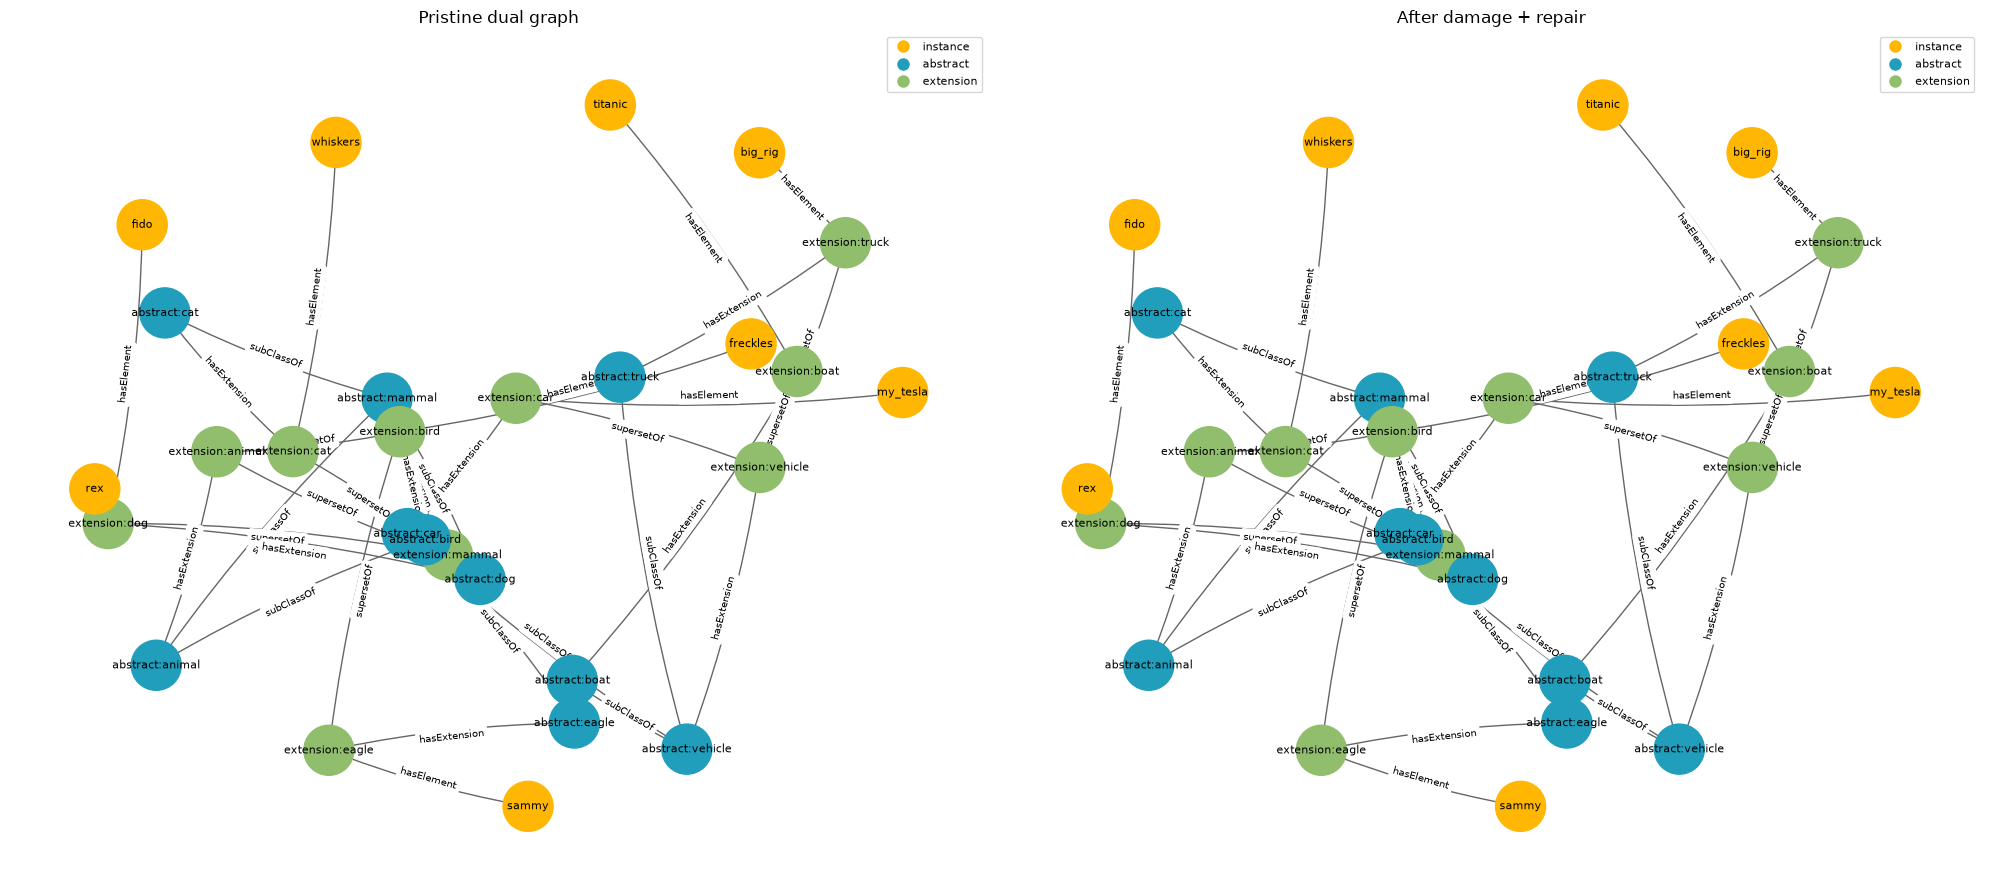

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
gu.visualize(dual_pristine, title='Pristine dual graph', ax=axes[0])
gu.visualize(dual, title='After damage + repair', ax=axes[1])
plt.tight_layout()
plt.show()

In [14]:
# Optional: write an interactive HTML view you can open in a browser.
try:
    out = gu.visualize_pyvis(dual, 'data/processed/class_thread_demo.html')
    print('Interactive graph written to:', out)
except Exception as exc:
    print('pyvis unavailable:', exc)

INFO src.graph_utils: Wrote interactive graph -> data/processed/class_thread_demo.html


Interactive graph written to: data/processed/class_thread_demo.html


## 8. (Optional) Real data — a WordNet noun subset

The same pipeline runs on a real WordNet subset if `nltk` + the `wordnet` corpus
are installed (`python -c "import nltk; nltk.download('wordnet')"`). It degrades
gracefully to a message otherwise.

In [15]:
try:
    wn_flat = gu.build_wordnet_graph(roots=['vehicle.n.01'], max_depth=2, config=cfg)
    wn_dual = p1.expand_to_dual_nodes(wn_flat, config=cfg)
    wn_report = p2.validate_threads(wn_dual, config=cfg)
    print('WordNet flat:', gu.describe_graph(wn_flat))
    print('WordNet dual:', gu.describe_graph(wn_dual))
    print(m.format_metrics(m.compute_metrics(wn_dual, config=cfg, report=wn_report)))
except Exception as exc:
    print('Skipping WordNet demo:', exc)

INFO src.graph_utils: Built WordNet flat graph: 96 nodes, 97 edges.


INFO src.process1_dual_node: Process 1: expanding 52/52 concept(s).


INFO src.process1_dual_node: Process 1 done: 148 nodes, 200 edges (52 abstract, 52 extension, 44 instance).


INFO src.process2_thread_enforce: Validation: {'expected_pairs': 131, 'valid_pairs': 131, 'broken_pairs': 0, 'coverage': 1.0}


WordNet flat: {'nodes': 96, 'edges': 97, 'node_kinds': {'concept': 52, 'instance': 44}, 'relations': {'subClassOf': 51, 'instanceOf': 46}}
WordNet dual: {'nodes': 148, 'edges': 200, 'node_kinds': {'abstract': 52, 'extension': 52, 'instance': 44}, 'relations': {'hasExtension': 52, 'supersetOf': 51, 'subClassOf': 51, 'hasElement': 46}}
  coverage                       : 100.0%  (131/131 pairs)
  broken threads                 : 0
  instances                      : 44
  avg valid threads / instance   : 2.9773


## Summary

* **Process 1** split each concept into `abstract:` + `extension:` nodes joined by `hasExtension`.
* A **Class Thread** is the uniform forward path `hasExtension -> supersetOf* -> hasElement`.
* **Process 2** validated coverage, and **conservatively repaired** broken threads.
* Threaded queries answer concept membership with **one pattern** instead of bespoke recursion.

The optional `src/neo4j_helpers.py` sketches how this maps onto Cypher for later migration.